# Assignment: 2D radioactive lighthouse location using MCMC

As before, a radioactive source that emits gamma rays randomly in time but uniformly in angle is placed at $(x_0, y_0)$.  The gamma rays are detected on the $x$-axis and these positions are saved, $x_k$, $k=1,2,\cdots, N$.  Given these observed positions, the problem is to estimate the location of the source.

Unlike before, we will not assume that $y_0$ is known. Your task is to estimate both $x_0$ and $y_0$.  Since we are using Bayesian methods, this means finding the joint posterior for $x_0$ and $y_0$, given the data on where the gamma rays were detected.

You will combine the results and Python code from the `radioactive_lighthouse_exercise.ipynb` and `parameter_estimation_Gaussian_noise-2.ipynb` notebooks, sampling the posterior using `emcee` and plotting it using `corner`.

## Learning goals:

* Be able to re-use markdown and Python from existing notebooks to perform similar tasks (even if not understanding all details); e.g., generating data, sampling via MCMC, making plots.
* Successfully apply the basic ideas of Bayesian statistics: Bayes theorem, priors, sampling of posteriors.
* Successfully analyze results (with hints).
* Try out markdown.

Note: you shouldn't need to recalculate anything; focus on the notebook ingredients.

## Expressions

The posterior we want is:

$$ p(x_0, y_0 | \{x_k\}, I) = \frac{p(\{x_k\} | x_0, y_0, I) * p(x_0, y_0 | I)}{p(\{x_k\} | I)}
$$

*Using $\LaTeX$, fill in the right side of the equation for Bayes' rule as it applies in this case.* 


*Then add below the expression for the likelihood in this case (replace the dots with the correct form and fill in the right side):*

$$  p(\{x_k\} | x_0, y_0, I) = \prod_{1}^{k_{max}} p(x_k | x_0, y_0, I) = \prod_{1}^{k_{max}}[ \frac{y_0}{\pi} \frac{1}{y_0^2 + (x_k - x_0)^2} ]\;
$$


*Describe in words what you will use for the prior:*

*Do you need to find an expression for the denominator pdf?  Explain.*
<br><br> I do not need to find an expression for the evidence, because it does not depend on any $x_0$ or $y_0$, so it is just a normalization factor that we can ignore.

## Python imports

You will need to import emcee and corner.  The best way to do this is to follow the instructions for making an environment (see Carmen page).  An alternative is to install them separately using (at the command line):

`conda install -c astropy emcee`

`conda install -c astropy corner`

In [22]:
import numpy as np
import emcee
import corner
%matplotlib inline   

import numpy as np

import scipy.stats as stats
from scipy.stats import cauchy, uniform

import matplotlib.pyplot as plt
import seaborn as sns; sns.set() # for plot formatting
#sns.set_context("talk")

## Generating the data

Copy-and-paste here the code from `radioactive_lighthouse_exercise.ipynb` used to generate the $x_k$ points.  Note that you have control over where the true position is but also the size of the dataset.  You will want to adjust both later. It is recommended to add the code that plots the distribution of the data (to verify it is the same as before), but this is not required.

maximum =  567.6367269124148
minimum =  -1105.6272496843549


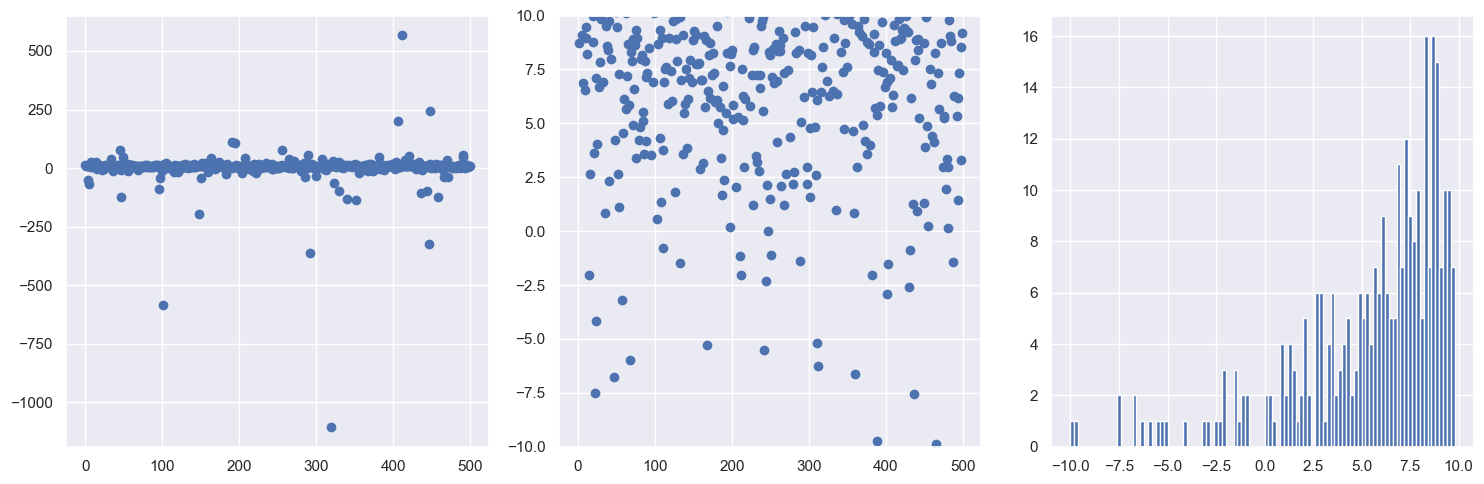

In [109]:
# Add code here to generate the dataset.  Start with 500 points.
np.random.seed(None)
# True location of the radioactive source
x0_true = 8
y0_true = 3.5

# Generate num_pts random numbers distributed according to dist and plot 
num_pts = 500
x_pts = np.arange(num_pts)

# Distribution knowing where the source is: scipy.stats.cauchy(loc, scale)
dist = cauchy(x0_true, y0_true)
dist_pts = dist.rvs(num_pts)

# Make some plots!
fig = plt.figure(figsize=(15,5))

# First plot all the points, letting it autoscale the counts
ax_1 = fig.add_subplot(1,3,1)
ax_1.scatter(x_pts, dist_pts)  

# Repeat but zoom in to near the origin
ax_2 = fig.add_subplot(1,3,2)
ax_2.scatter(x_pts, dist_pts)
ax_2.set_ylim(-10.,10.)

# Finally make a zoomed-in histogram
ax_3 = fig.add_subplot(1,3,3)
out = ax_3.hist(dist_pts, bins=np.arange(-10., 10., 0.2))

# Print out the numerical limits (max and min)
print('maximum = ', np.amax(dist_pts))
print('minimum = ', np.amin(dist_pts))

fig.tight_layout()
#print(dist_pts)

## PDFs for applying Bayes' rule

*Adapt code from the two notebooks to express the logarithms of the prior, likelihood, and posterior for this case.*

In [110]:
# Add code for the log_prior, log_likelihood, and log_posterior

min_theta=np.array([-10,0.1])
max_theta=np.array([10,4])
volume_theta=np.prod(max_theta-min_theta)

def log_prior(theta):
    '''Log prior for parameter array theta'''
    assert len(theta)==2, "Parameter vector must have length two."
    # flat prior 
    if np.logical_and(min_theta<=theta, theta<=max_theta).all(): 
        return np.log(1/volume_theta)
    else:
        return -np.inf
    
def log_likelihood(theta, X): 
    """
    Log likelihood for the first N_max points of the dist_pts array,
    assuming independent.  Not normalized!
    """
    if (theta[1] <= 0):
        return -np.inf
    try:
        return np.sum(np.log(theta[1] / np.pi / (theta[1]**2 + (X - theta[0])**2)  ))
    except ValueError:
        return -np.inf

def log_posterior(theta, X):
    '''Log posterior for data X given parameter array theta'''
    return log_prior(theta) + log_likelihood(theta, X)

## Run MCMC

*Copy code to run `emcee` and make any necessary changes.*

In [111]:
print(log_posterior([2, 1.5], dist_pts))

-2413.913649953188


In [112]:
# Add the code to run emcee
ndim = 2  # number of parameters in the model
nwalkers = 50  # number of MCMC walkers
nburn = 1000  # "burn-in" period to let chains stabilize
nsteps = 1000  # number of MCMC steps to take

# we'll start at random locations within the prior volume
starting_guesses = min_theta + \
                   (max_theta - min_theta) * np.random.rand(nwalkers,ndim)

print("MCMC sampling using emcee (affine-invariant ensamble sampler) with {0} walkers".format(nwalkers))
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[dist_pts])

# "burn-in" period; save final state and then reset
#print(starting_guesses)
state = sampler.run_mcmc(starting_guesses, nburn)
sampler.reset()

# sampling period
sampler.run_mcmc(state, nsteps)

print("Mean acceptance fraction: {0:.3f} (in total {1} steps)"
                .format(np.mean(sampler.acceptance_fraction),nwalkers*nsteps))

# discard burn-in points and flatten the walkers; the shape of samples is (nwalkers*nsteps, ndim)
samples = sampler.chain.reshape((-1, ndim))

MCMC sampling using emcee (affine-invariant ensamble sampler) with 50 walkers
Mean acceptance fraction: 0.714 (in total 50000 steps)


## Generate figures

Note: you do not need to do the maximum likelihood estimates that were added to the corner plot for the Gaussian noise case.  You can skip that part of the code.

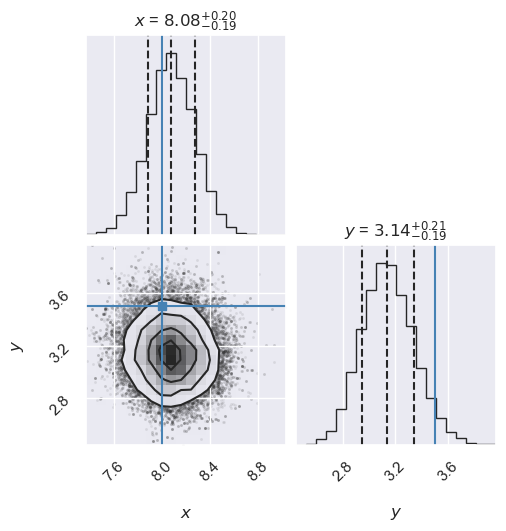

In [113]:
# Add the code to make a corner plot
# make a corner plot with the posterior distribution
fig = corner.corner(samples, labels=["$x$", "$y$"],
                    truths=[x0_true, y0_true],quantiles=[0.16, 0.5, 0.84],
                    show_titles=True, title_kwargs={"fontsize": 12})

## Analysis

Summarize the results for the following investigations.  You can simply add to the cell containing the questions or else start new cells.

1. *Run the notebook 10 times (which will generate 10 different sets of random data).  Record the values of $x_0$ and $y_0$ and their uncertainties given on the corner plot for each run.  Is the actual spread of values consistent with the given uncertainties?*

<br><br>
x=0.97 +- 0.06, y=0.98 +- 0.06<br>
x=0.92 +- 0.06, y=0.96 +- 0.06<br>
x=1.13 +- 0.06, y=0.99 +0.07 -0.06<br>
x=1.11 +0.07 -0.06, y=1.08 +-0.07<br>
x=1.09 +-0.06, y=0.97 +=0.06<br>
x=1.06 +-0.06, y=0.94 +-0.06<br>
x=0.97 +-0.07, y=1.10 +-0.07<br>
x=1.14 +-0.07, y=1.04 +0.07 -0.06<br>
x=1.03 +-0.06, y=1.01 +0.07 -0.06<br>
x=0.90 +-0.06, y=1.00 +-0.06<br>
<br>
yynynynnnyyyynnyyyyny
<br>
13/20 times, or about 2/3 of the time, the model true value is within the range of predicted values.
<br>

<br>

3. *Increase the number of data points by a factor of 10.  By how much does the width of the posterior shrink?  Is this expected?* <br/><br/>
It decreases the uncertainty from about 0.06 to 0.02, which is about $\sqrt{10}$, which is the expected change in uncertainty for Monte Carlo
4. *What does increasing the number of MC steps per walker do?* <br/><br/>
Changing the number of steps per walker did not change the uncertainty, but after running it 6 times it agreed with the real value every time.

5. *Try changing `x0_true` and `y0_true`.  Does it still work?* <br/><br/>
When I move the true position close to the pror boundaries it doesn't work as well. Outside of the boundaries it doesn't work at all unsurprisingly. Changing the true y position makes the uncertainty higher which makes sense, since the distance from the true x position to any detection is linearly dependent on the y position, so the uncertainty should be as well.